**Installing all the dependencies**

In [1]:
!pip install qiskit[all] qiskit-aer

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 34.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 56.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 39.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.6/49.6 MB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 33.0/33.0 MB 38.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 541.5/541.5 kB 19.4 MB/s eta 0:00:00
  Created wheel for python-constraint: filename=python_constraint-1.4.0-py2.py3-none-any.whl size=24061 sha256=fb6dbfda40890c33b92e715ca63d45bf0a46a51dde5df42e523d8ad5a95fa22a
  Stored in directory: /root/.cache/pip/wheels/c1/d2/3d/082849b61a9c6de02d4a7c8a402c224640f08d8a971307b92b
Successfully built python-constraint


**Importing all the required libraries/modules**

In [2]:
import numpy as np
from qiskit.quantum_info import SparsePauliOp, Statevector
from qiskit import *
from scipy.optimize import minimize
import matplotlib.pyplot as plt
from qiskit_aer import Aer
from qiskit.visualization import plot_histogram
from qiskit.circuit.library import UnitaryGate
from scipy.linalg import expm
import time
from math import floor

**Defining all necessary functions**

Hamiltonian = risk - returns + constraint

In [8]:
#Ising model to build the Hamiltonian
def generate_binary_operators(num_of_assets):
  x = []
  for i in range(num_of_assets):
    op_str = list("I"*num_of_assets)
    op_I = SparsePauliOp("".join(op_str))
    op_str[i] = "Z"
    op_str = op_str[::-1]
    op_Z = SparsePauliOp("".join(op_str))
    op_x = (op_I - op_Z)/2
    x.append(op_x)
  return x

#Generate risk terms of the Hamiltonian
def risk_term(covariance, x, num_of_assets):
  risk = 0
  for i in range(num_of_assets):
    for j in range(num_of_assets):
      risk += covariance[i][j]*(x[i]@x[j])
  return risk

#Generate return terms of the Hamiltonian
def return_term(returns, x, num_of_assets):
  rtn = 0
  for i in range(num_of_assets):
    rtn += returns[i]*x[i]
  return rtn

#Generate constraint terms of the Hamiltonian
def constraint_term(x, k, num_of_assets):
  constraint = x[0]*0
  for i in range(num_of_assets):
    constraint += x[i]
  constraint -= k*SparsePauliOp("I"*num_of_assets)
  return constraint @ constraint

#Defining the circuit for Hardware-Efficient ansatz
def hardware_efficient_ansatz(num_qubits, params):
    qc = QuantumCircuit(num_qubits, num_qubits)
    for i in range(num_qubits):
        qc.ry(params[i], i)
    for i in range(num_qubits - 1):
        qc.cx(i, i + 1)
    offset = num_qubits
    for i in range(num_qubits):
        qc.ry(params[offset + i], i)
    return qc

#Parametric circuit for Hardware-Efficient ansatz (tuned by classical optimizer)
def parametric_circuit_he(params):
  qc = hardware_efficient_ansatz(num_of_assets, params)
  state = Statevector.from_instruction(qc)
  energy = np.real(state.expectation_value(H))
  return energy

#Constructs the ladder operators which excites/de-excites the state
def ladder_operators(num_of_assets):
  a = []
  a_dag = []
  for i in range(num_of_assets):
    pauliStr1 = list("I"*num_of_assets)
    pauliStr2 = list("I"*num_of_assets)
    pauliStr1[i] = "X"
    pauliStr2[i] = "Y"
    pauliStr1 = "".join(pauliStr1[::-1])
    pauliStr2 = "".join(pauliStr2[::-1])
    a.append(1/2*(SparsePauliOp(pauliStr1) + 1j*SparsePauliOp(pauliStr2)))
    a_dag.append(1/2*(SparsePauliOp(pauliStr1) - 1j*SparsePauliOp(pauliStr2)))
  return a, a_dag

#Generate all possible basis states (in this case number of assets has been conserved)
def generate_basis(num_of_assets, k):
  basis_list = []
  for i in range(2**num_of_assets):
    basis = list(format(i, f'0{num_of_assets}b'))
    if basis.count("1") == k:
      basis_list.append("".join(basis))
  return basis_list

#Check if single or double excitation needed to go from b1 to b2 (they are two states)
def find_excitation_level(b1, b2):
  count = 0
  for i, j in zip(b1, b2):
    if i != j:
      count += 1
  return count

#Unitary Coupled Cluster ansatz with Single and Double excitations
def UCCSD_ansatz(params, singles, doubles):
  T = 0
  for ind, (i, j) in enumerate(singles):
    T += params[ind]*(a_dag[i] @ a[j])
  for ind, (i, j, k, l) in enumerate(doubles):
    T += params[len(singles)+ind]*(a_dag[i] @ a_dag[j] @ a[k] @ a[l])

  T_dag = T.adjoint()
  A = T - T_dag
  UCCSD = UnitaryGate(expm(A))

  qc = QuantumCircuit(num_of_assets, num_of_assets)
  qc.x([ind for ind, elem in enumerate(basis[0][::-1]) if elem == "1"])
  qc.append(UCCSD, range(num_of_assets))
  return qc

#Circuit which the VQE tunes
def parametric_circuit_UCCSD(params):
  qc = UCCSD_ansatz(params, singles, doubles)
  state = Statevector.from_instruction(qc)
  energy = np.real(state.expectation_value(H))
  return energy

#Find all possible excitations from all the states
def find_excitations(basis):
  single_excitations = []
  double_excitations = []

  for ind1, b1 in enumerate(basis):
      for ind2, b2 in enumerate(basis):
        b1, b2 = list(b1), list(b2)
        b1_indices = [i for i, x in enumerate(b1) if x == "1"]
        b2_indices = [i for i, x in enumerate(b2) if x == "1"]
        if b1 != b2:
            excitation_level = find_excitation_level(b1_indices, b2_indices)
            if excitation_level == 1:
              for i , j in zip(b1_indices, b2_indices):
                if i != j:
                  single_excitations.append((i, j))
            if excitation_level == 2:
              from_orb = []
              to_orb = []
              for i, j in zip(b1_indices, b2_indices):
                if i != j:
                  from_orb.append(i)
                  to_orb.append(j)
              double_excitations.append(tuple(from_orb + to_orb))
  return single_excitations, double_excitations

#generates synthetic data
def generate_returns(num_assets, low=0.05, high=0.20, seed=None):
  rng = np.random.default_rng(seed)
  return rng.uniform(low, high, num_assets)

def generate_covariance(num_assets, scale=0.05, seed=None):
  rng = np.random.default_rng(seed)
  A = rng.normal(size=(num_assets, num_assets))
  covariance = A @ A.T
  covariance *= scale / np.max(np.diag(covariance))
  return covariance

**Classical diagonalization**

In [10]:
def classical_diagonalization():
  start = time.perf_counter()
  eigenvalues, eigenvectors = np.linalg.eigh(H.to_matrix())
  ground_energy = eigenvalues[0]
  ground_state = eigenvectors[:, 0]
  end = time.perf_counter()
  exe_time = end - start
  print("Ground energy:", ground_energy)
  probabilities = np.abs(ground_state)**2

  idx = np.argmax(probabilities)

  bitstring = format(idx, f'0{num_of_assets}b')

  print("Ground state:", bitstring)
  print("Time:", exe_time, "s")
  return exe_time, bitstring

**VQE (hardware efficient ansatz)**

In [12]:
def vqe_hardware_efficient():
  start = time.perf_counter()
  result_vqe_he = minimize(
      parametric_circuit_he,
      x0=np.zeros(2*num_of_assets),
      method="COBYLA"
  )
  end = time.perf_counter()
  exe_time = end - start
  print("Optimized theta:")
  print(result_vqe_he.x)
  print("Ground state energy:", result_vqe_he.fun)

  qc_ground_state = hardware_efficient_ansatz(num_of_assets, result_vqe_he.x)
  qc_ground_state.measure(range(num_of_assets), range(num_of_assets))
  simulator = Aer.get_backend("qasm_simulator")
  tc = transpile(qc_ground_state, simulator)
  job = simulator.run(tc, shots = 1000)
  result = job.result()
  counts = result.get_counts()
  ground_state = max(counts, key=counts.get)
  print("Ground state:", ground_state)
  print("Time:", exe_time, "s")
  return exe_time, ground_state

**VQE (UCCSD ansatz)**

In [11]:
def vqe_UCCSD():
  start = time.perf_counter()
  result_vqe_UCCSD = minimize(
      parametric_circuit_UCCSD,
      x0=np.zeros(len(singles)+len(doubles)),
      method="COBYLA"
  )
  end = time.perf_counter()
  exe_time = end - start

  print("Optimized theta:")
  print(result_vqe_UCCSD.x)
  print("Ground state energy:",result_vqe_UCCSD.fun)

  qc_ground_state = UCCSD_ansatz(result_vqe_UCCSD.x, singles, doubles)
  qc_ground_state.measure(range(num_of_assets), range(num_of_assets))
  simulator = Aer.get_backend("qasm_simulator")
  tc = transpile(qc_ground_state, simulator)
  job = simulator.run(tc, shots = 1000)
  result = job.result()
  counts = result.get_counts()
  ground_state = max(counts, key=counts.get)
  print("Ground state:", ground_state)
  print("Time:", exe_time, "s")
  return exe_time, ground_state

**Results**

In [14]:
m_list = [3, 4, 5, 6]
t_list = {
    0:[],
    1:[],
    2:[]
}
result_list = {
    0:[],
    1:[],
    2:[]
}

for m in m_list:
  returns = generate_returns(m, seed = 42)
  covariance = generate_covariance(m, seed = 42)

  lambda_ = 2
  penalty = 2
  k = floor(m/2)

  num_of_assets = covariance.shape[0]
  x = generate_binary_operators(num_of_assets)
  H_risk = risk_term(covariance, x, num_of_assets)
  H_returns = return_term(returns, x, num_of_assets)
  a, a_dag = ladder_operators(num_of_assets)
  H_constraint = constraint_term(x, k, num_of_assets)
  basis = generate_basis(num_of_assets, k)
  singles, doubles = find_excitations(basis)

  H = H_risk - lambda_*H_returns + penalty*H_constraint

  print("Classical diagonalization:")
  t_classical, result_classical = classical_diagonalization()
  t_list[0].append(t_classical)
  result_list[0].append(result_classical)
  print("\nVQE with hardware efficient ansatz:")
  t_hardware_efficient, result_hardware_efficient = vqe_hardware_efficient()
  t_list[1].append(t_hardware_efficient)
  result_list[1].append(result_hardware_efficient)
  print("\nVQE with UCCSD ansatz:")
  t_UCCSD, result_UCCSD = vqe_UCCSD()
  t_list[2].append(t_UCCSD)
  result_list[2].append(result_UCCSD)
  print("\n", "="*60, "\n")

Classical diagonalization:
Ground energy: -0.3566662934100806
Ground state: 100
Time: 0.0003696210001180589 s

VQE with hardware efficient ansatz:
Optimized theta:
[ 0.71977146  1.5708033   4.71114612 -0.71979432  1.57075056 -1.57083048]
Ground state energy: -0.3566662236880589
Ground state: 100
Time: 3.806588758000089 s

VQE with UCCSD ansatz:
Optimized theta:
[-0.03539544  1.25700476 -0.38037589 -0.44836613 -0.28610565 -0.7933228 ]
Ground state energy: -0.35666629337302247
Ground state: 100
Time: 0.7964553429999341 s


Classical diagonalization:
Ground energy: -0.6498957000131916
Ground state: 1100
Time: 0.00020372500011944794 s

VQE with hardware efficient ansatz:
Optimized theta:
[-1.04377296 -1.56853039  1.57087839  3.12389882  2.09781581  1.5696818
 -0.85366717  0.855618  ]
Ground state energy: -0.617099567414872
Ground state: 1001
Time: 9.711156430999836 s

VQE with UCCSD ansatz:
Optimized theta:
[ 0.9823452   1.01307555  0.18278839  0.32043002  0.30489132  0.18925136
  0.131055

**Plot shows how each method scales**

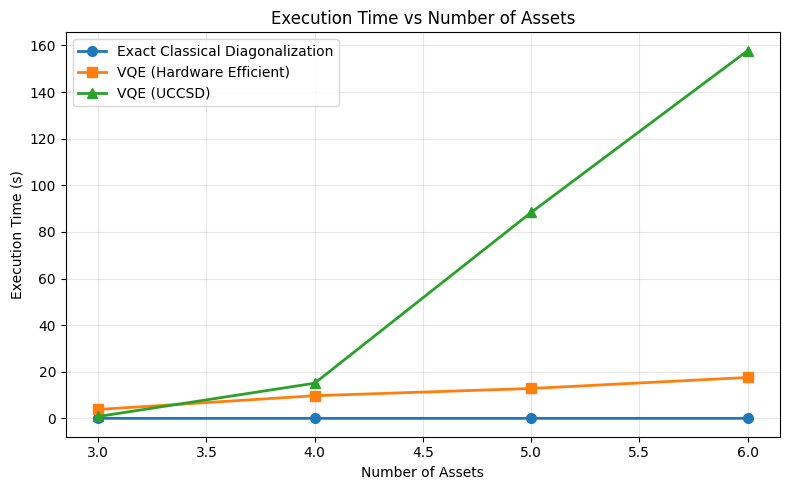

In [15]:
plt.figure(figsize=(8,5))
plt.plot(
    m_list,
    t_list[0],
    marker='o',
    linewidth=2,
    markersize=7,
    label='Exact Classical Diagonalization'
)
plt.plot(
    m_list,
    t_list[1],
    marker='s',
    linewidth=2,
    markersize=7,
    label='VQE (Hardware Efficient)'
)
plt.plot(
    m_list,
    t_list[2],
    marker='^',
    linewidth=2,
    markersize=7,
    label='VQE (UCCSD)'
)

plt.xlabel("Number of Assets")
plt.ylabel("Execution Time (s)")
plt.title("Execution Time vs Number of Assets")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

**Comparing the accuracy of UCCSD and Hardware-Efficient ansatz**

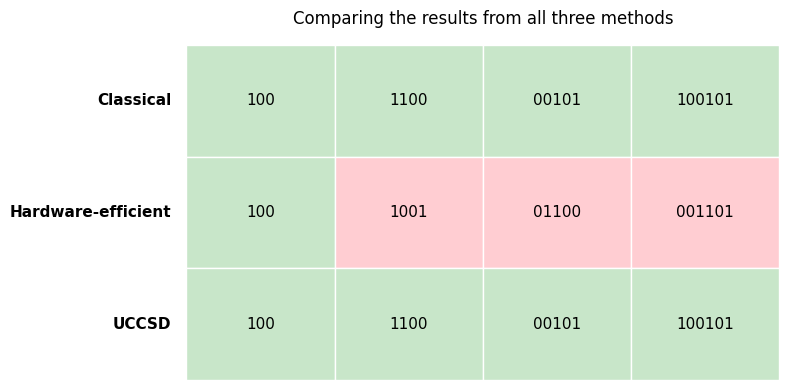

In [18]:
labels = ['Classical', 'Hardware-efficient', 'UCCSD']
n_rows = len(result_list)
n_cols = len(result_list[0])

fig, ax = plt.subplots(figsize=(8, 4))
ax.set_xlim(0, n_cols)
ax.set_ylim(0, n_rows)
ax.invert_yaxis()
ax.axis('off')

for row, key in enumerate(result_list):
    for col, bits in enumerate(result_list[key]):
        match = bits == result_list[0][col]
        color = '#c8e6c9' if match else '#ffcdd2'  # green if match, red if not
        ax.add_patch(plt.Rectangle((col, row), 1, 1, facecolor=color, edgecolor='white'))
        ax.text(col + 0.5, row + 0.5, bits, ha='center', va='center', fontsize=11)

for row, name in enumerate(labels):
    ax.text(-0.1, row + 0.5, name, ha='right', va='center', fontsize=11, fontweight='bold')

ax.set_title('Comparing the results from all three methods', pad=15)
plt.tight_layout()
plt.savefig('bitstring_comparison.png', dpi=150)
plt.show()